Le programme commence par importer les bibliothèques nécessaires à l’analyse financière et à la visualisation des données. La bibliothèque yfinance est utilisée pour télécharger les données du taux de change EUR/USD sur une période d’un an avec une fréquence quotidienne. Les données récupérées sont stockées dans un tableau (DataFrame) contenant les prix journaliers

In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ticker = "EURUSD=X"
data = yf.download(ticker, period="1y", interval="1d")

# Calcul des rendements quotidiens
data['Returns'] = data['Close'].pct_change()

# CORRECTION ICI : On utilise .squeeze() et float() pour extraire le chiffre pur
S0 = float(data['Close'].squeeze().iloc[-1])
volatilite_annuelle = float(data['Returns'].squeeze().std() * np.sqrt(252))

print(f"Taux actuel (EUR/USD) : {S0:.4f}")
print(f"Volatilité historique annualisée : {volatilite_annuelle:.2%}")




[*********************100%***********************]  1 of 1 completed

Taux actuel (EUR/USD) : 1.1776
Volatilité historique annualisée : 7.79%



À partir du prix de clôture, le code calcule les rendements journaliers du taux de change. Ces rendements permettent de mesurer les variations quotidiennes du marché. Ensuite, l’écart-type des rendements est calculé afin d’estimer la volatilité historique. Cette volatilité est annualisée en utilisant la racine carrée de 252, correspondant au nombre approximatif de jours de marché par an. Le dernier taux observé est également extrait afin de servir de référence pour la simulation.

In [15]:

Chiffre_Affaires_USD = 100_000_000  # Ex: 100 Millions $ de ventes
Couts_Fixes_EUR = 80_000_000        # 80 Millions € de coûts



In [16]:
N_simulations = 10000
taux_futurs = np.random.normal(S0, S0 * volatilite_annuelle, N_simulations)

Le modèle suppose qu’une entreprise réalise 100 millions de dollars de chiffre d’affaires et supporte 80 millions d’euros de coûts fixes. Cette configuration illustre une situation classique d’exposition au risque de change : les revenus sont libellés en USD tandis que les coûts sont en EUR.

In [17]:
#sans couverture
Resultat_Non_Couvert = (Chiffre_Affaires_USD / taux_futurs) - Couts_Fixes_EUR

#Avec couverture
Taux_Forward = S0
Resultat_Couvert = (Chiffre_Affaires_USD / Taux_Forward) - Couts_Fixes_EUR

# C) Calcul de la Value at Risk (VaR à 95%)
var_95 = np.percentile(Resultat_Non_Couvert, 5)
print(f"Résultat espéré avec couverture : {Resultat_Couvert / 1e6:.2f} Millions €")
print(f"Value at Risk (Pire cas à 95%) sans couverture : {var_95 / 1e6:.2f} Millions €")

Résultat espéré avec couverture : 4.92 Millions €
Value at Risk (Pire cas à 95%) sans couverture : -4.53 Millions €


Dans le scénario non couvert, les revenus en dollars sont convertis en euros en utilisant les taux simulés. Le résultat net varie donc selon les fluctuations du taux de change. Cela permet d’observer l’impact direct du risque de change sur la rentabilité.
Dans le scénario couvert, un taux forward égal au taux actuel est supposé. Le taux de conversion est donc fixé à l’avance, ce qui supprime l’incertitude liée aux fluctuations du marché. Le résultat devient stable et indépendant des scénarios simulés.

La Value at Risk à 95 % est calculée à partir de la distribution des résultats non couverts. Elle représente le seuil en dessous duquel se situent les 5 % pires scénarios. Cette mesure permet de quantifier la perte potentielle maximale dans un cadre probabiliste.

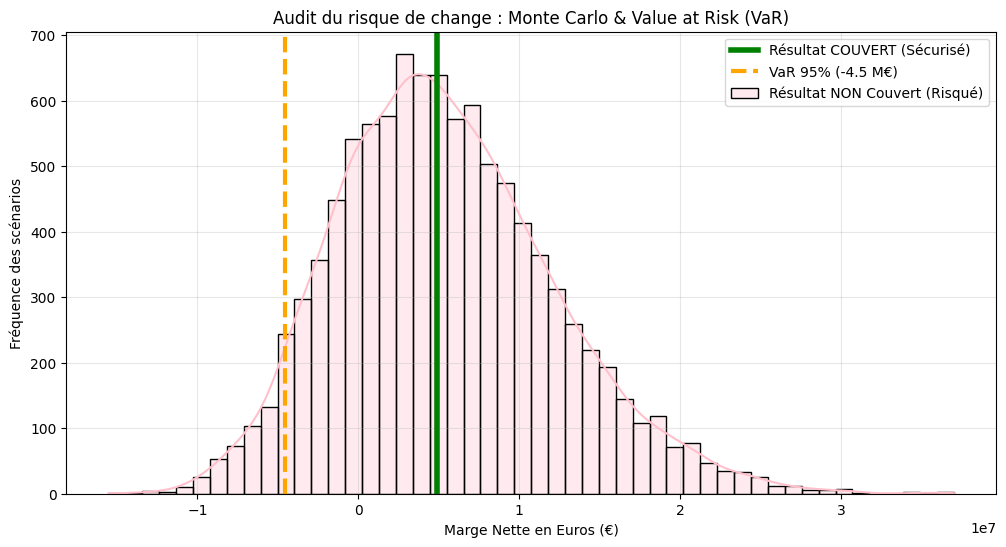

In [18]:
plt.figure(figsize=(12, 6))

# Histogramme
sns.histplot(Resultat_Non_Couvert, bins=50, kde=True, color='pink', alpha=0.3, label='Résultat NON Couvert (Risqué)')

# Lignes de référence
plt.axvline(x=Resultat_Couvert, color='green', linewidth=4, label='Résultat COUVERT (Sécurisé)')

# Ligne de la VaR
plt.axvline(x=var_95, color='orange', linewidth=3, linestyle='--', label=f'VaR 95% ({var_95/1e6:.1f} M€)')

# pour qu'il soit bg (imane aime le rose desolé paul)
plt.title("Audit du risque de change : Monte Carlo & Value at Risk (VaR)")
plt.xlabel("Marge Nette en Euros (€)")
plt.ylabel("Fréquence des scénarios")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Le graphique final illustre la distribution des résultats non couverts, la position du résultat couvert et la Value at Risk. Il met visuellement en évidence que la couverture réduit significativement la volatilité du résultat net.